# Fan Affinity Laws

The Fan Affinity Laws are non-dimensional scaling relations derived from fluid dynamics principles governing geometrically similar turbomachinery (homologous fans).

We define the primary variables involved:

* $D$: Impeller diameter $[\text{m}]$
* $\omega$: Rotational speed $[\text{rad/s}]$
* $\rho$: Fluid density $[\text{kg/m}^3]$
* $\dot{V}$: Volumetric flow rate $[\text{m}^3/\text{s}]$
* $\Delta p$: Pressure rise across the fan $[\text{Pa}]$
* $\dot{W}_\text{sh}$: Shaft power consumed $[\text{W}]$

From kinematic and dynamic similarity, we know that the linear velocity of the fan blade tip scales proportionally with rotational speed and impeller diameter:

$$v \propto \omega D \tag{1}$$

We also know that the flow cross-sectional area scales with the square of the impeller diameter:

$$A \propto D^2 \tag{2}$$

The volumetric flow rate is the product of flow cross-sectional area and fluid velocity ($\dot{V} = A \cdot v$). Substituting Equations (1) and (2) into this flow rate definition yields:

$$\dot{V} \propto A \cdot v \propto (D^2) \cdot (\omega D) = \omega D^3 \tag{3}$$

For a given, fixed fan ($D_1 = D_2$), taking the ratio of Equation (3) at two operating speeds gives:

$$\frac{\dot{V}_1}{\dot{V}_2} = \frac{\omega_1}{\omega_2} \tag{4}$$

That is, the volumetric flow rate varies linearly with fan rotational speed.

The pressure differential across a fan is governed by dynamic pressure ($\frac{1}{2}\rho v^2$), which scales with fluid density and the square of velocity. Substituting Equation (1) into this dynamic pressure scaling yields:

$$\Delta p \propto \rho v^2 \propto \rho (\omega D)^2 = \rho \omega^2 D^2 \tag{5}$$

For a given fan ($D_1 = D_2$) operating in air of constant density ($\rho_1 = \rho_2$), taking the ratio of Equation (5) at two operating speeds gives:

$$\frac{\Delta p_1}{\Delta p_2} = \left(\frac{\omega_1}{\omega_2}\right)^2 \tag{6}$$

That is, the static pressure capability varies quadratically with fan rotational speed.

The ideal fluid power is defined as the volumetric flow rate multiplied by the pressure differential ($\dot{W}_\text{fluid} = \dot{V} \cdot \Delta p$). Assuming constant fan efficiency ($\eta$):

$$\dot{W}_\text{sh} = \frac{\dot{V} \cdot \Delta p}{\eta} \propto \dot{V} \cdot \Delta p \tag{7}$$

Substituting Equation (3) for $\dot{V}$ and Equation (5) for $\Delta p$ into Equation (7) yields:

$$\dot{W}_\text{sh} \propto (\omega D^3) \cdot (\rho \omega^2 D^2) = \rho \omega^3 D^5 \tag{8}$$

For a given fan ($D_1 = D_2$) operating in air of constant density ($\rho_1 = \rho_2$), taking the ratio of Equation (8) at two operating speeds gives:

$$\frac{\dot{W}_{\text{sh}, 1}}{\dot{W}_{\text{sh}, 2}} = \left(\frac{\omega_1}{\omega_2}\right)^3 \tag{9}$$

The shaft power consumption varies cubically with fan rotational speed. To connect these fluid dynamic principles to data center thermal limits, let's consider the following example.

## Example

Consider a steady-flow system with a control volume drawn around a server rack chassis with air entering at temperature $T_{\text{in}}$ and exiting at temperature $T_{\text{out}}$. Applying the First Law of Thermodynamics for an ideal gas with constant specific heat ($c_p$):

$$\dot{Q}_{\text{net}} - \dot{W}_{\text{net}} = \dot{m} c_p (T_{\text{out}} - T_{\text{in}}) \tag{10}$$

Assuming adiabatic chassis walls ($\dot{Q}_{\text{net}} = 0$) and substituting the net work input into the air stream as the sum of rack IT power ($P_{\text{IT}}$) and fan shaft power ($\dot{W}_{\text{sh}}$), Equation (10) simplifies to:

$$P_{\text{IT}} + \dot{W}_{\text{sh}} = \dot{m} c_p (T_{\text{out}} - T_{\text{in}}) \tag{11}$$

Substituting the mass flow rate relation $\dot{m} = \rho \dot{V}$ into Equation (11) yields:

$$P_{\text{IT}} + \dot{W}_{\text{sh}} = \rho \dot{V} c_p (T_{\text{out}} - T_{\text{in}}) \tag{12}$$

The fan shaft power ($\dot{W}_{\text{sh}}$) required to drive a volumetric flow rate $\dot{V}$ across a pressure drop $\Delta p$ with fan efficiency $\eta_{\text{fan}}$ is defined as:

$$\dot{W}_{\text{sh}} = \frac{\dot{V} \Delta p}{\eta_{\text{fan}}} \tag{13}$$

Assuming a linear fluid resistance model ($\Delta p = R_{\text{flow}} \dot{V}$) and substituting this pressure drop relationship into Equation (13) gives:

$$\dot{W}_{\text{sh}} = \frac{R_{\text{flow}}}{\eta_{\text{fan}}} \dot{V}^2 \tag{14}$$

Substituting Equation (14) for $\dot{W}_{\text{sh}}$ into Equation (12) gives the general governing energy balance as a function of volumetric flow rate $\dot{V}$:

$$P_{\text{IT}} + \frac{R_{\text{flow}}}{\eta_{\text{fan}}} \dot{V}^2 = \rho \dot{V} c_p (T_{\text{out}} - T_{\text{in}}) \tag{15}$$

Rearranging Equation (15) to solve explicitly for $T_{\text{out}}$:

$$T_{\text{out}}(\dot{V}) = T_{\text{in}} + \frac{P_{\text{IT}}}{\rho c_p \dot{V}} + \left( \frac{R_{\text{flow}}}{\eta_{\text{fan}} \rho c_p} \right) \dot{V} \tag{16}$$

In standard server rack operations, the airflow rate $\dot{V}$ is set to meet a target nominal temperature rise ($\Delta T_{\text{desired}}$) based solely on IT power:

$$\dot{V} = \frac{P_{\text{IT}}}{\rho c_p \Delta T_{\text{desired}}} \tag{17}$$

Substituting Equation (17) for $\dot{V}$ into Equation (16) yields the final explicit formula for actual outlet air temperature as a function of rack IT power ($P_{\text{IT}}$):

$$T_{\text{out}}(P_{\text{IT}}) = T_{\text{in}} + \Delta T_{\text{desired}} + \left( \frac{R_{\text{flow}}}{\eta_{\text{fan}} (\rho c_p)^2 \Delta T_{\text{desired}}} \right) P_{\text{IT}} \tag{18}$$

### Parameter Definitions

* $T_{\text{in}}$: Inlet air temperature $[\text{°C}]$
* $\Delta T_{\text{desired}}$: Target nominal temperature rise $[\text{°C}]$
* $P_{\text{IT}}$: Total rack IT power $[\text{W}]$
* $R_{\text{flow}}$: Linear flow resistance constant $[\text{Pa}/(\text{m}^3/\text{s})]$
* $\eta_{\text{fan}}$: Combined fan efficiency $[-]$
* $\rho$: Air density $[\text{kg/m}^3]$
* $c_p$: Specific heat capacity of air $[\text{J/(kg}\cdot\text{K)}]$

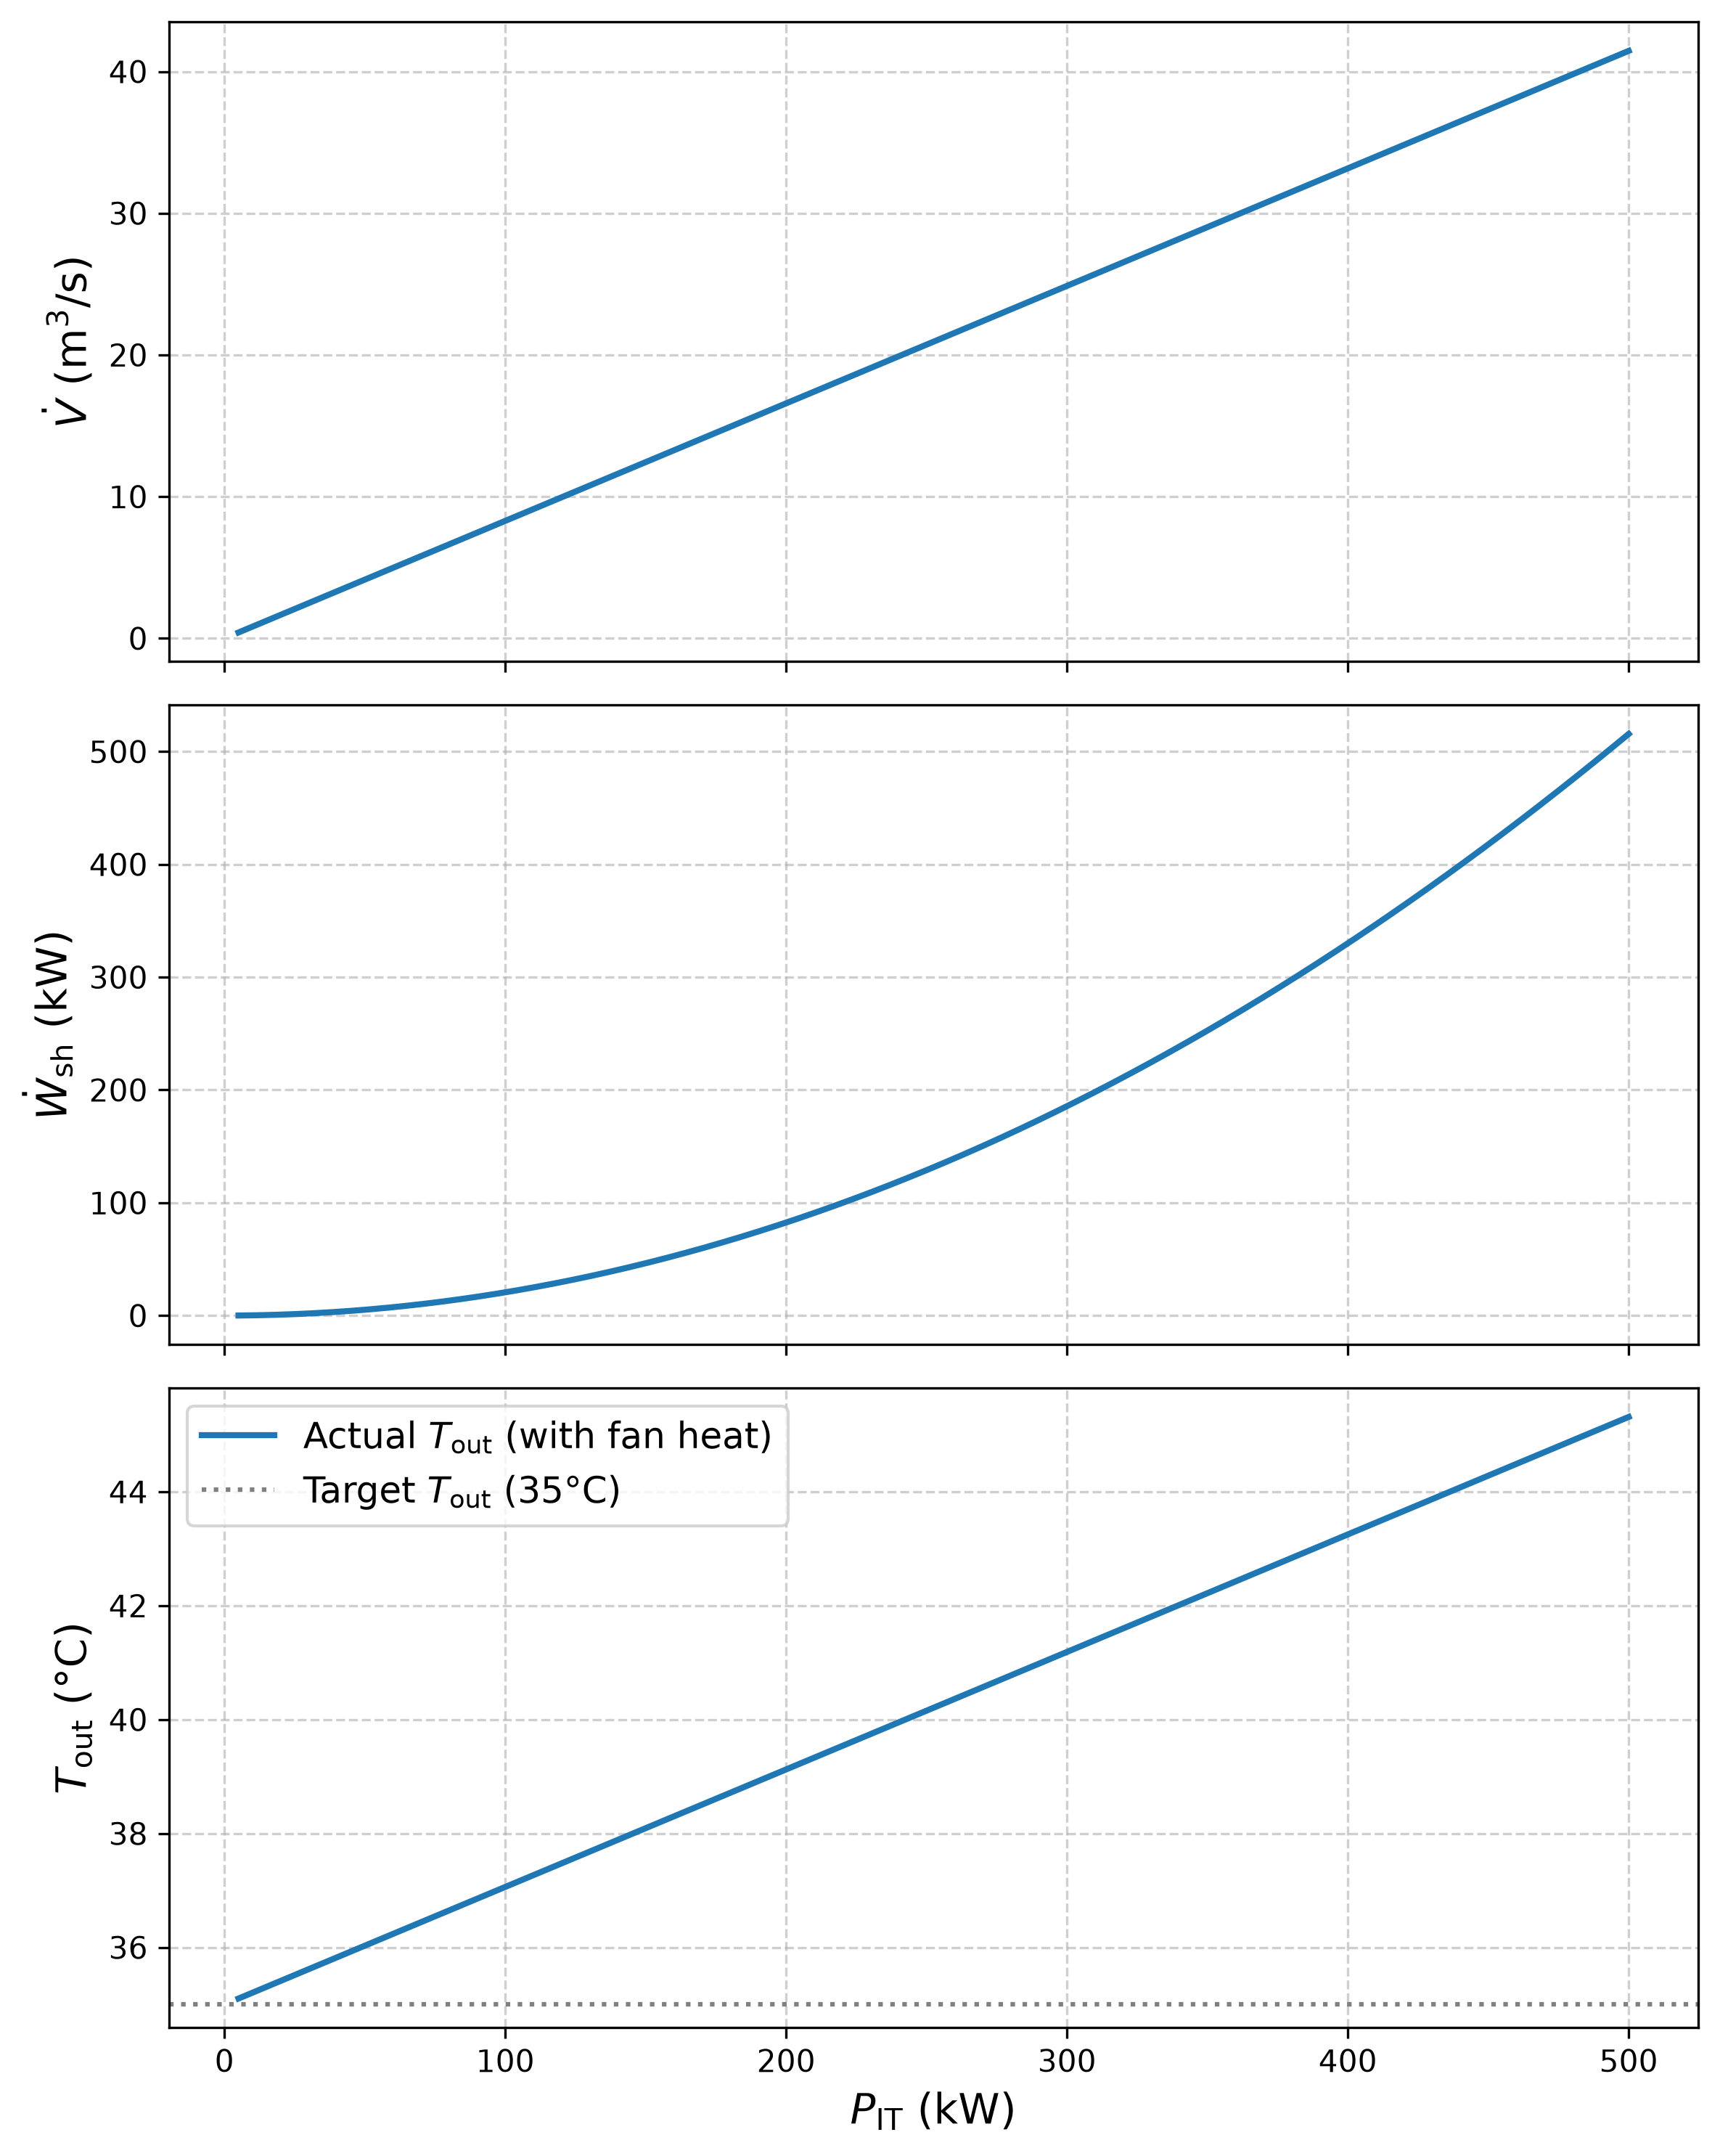

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# inputs
T_in = 25.0              # Inlet air temperature [°C]
delta_T_desired = 10.0   # Nominal target temperature rise [°C]
rho = 1.2                # Air density [kg/m^3]
cp = 1005                # Specific heat capacity of air [J/(kg·K)]
eta_fan = 0.50           # Combined fan efficiency [-]
R_flow = 150.0           # Constant linear flow resistance [Pa / (m^3/s)]
P_IT_kW = np.linspace(5.0, 500.0, 300)

# conversions
P_IT = P_IT_kW * 1e3     # Convert to Watts [W]

# calculations
# volumetric flow rate required for IT heat load
V_dot = P_IT / (rho * cp * delta_T_desired)  # [m^3/s]

# fan shaft power with linear flow resistance (Δp = R_flow * V_dot)
W_sh = (R_flow / eta_fan) * (V_dot**2)        # [W]
W_sh_kW = W_sh / 1e3                          # Convert to [kW]

# actual air outlet temperature including fan heat dissipation
T_out_actual = T_in + delta_T_desired + (R_flow / (eta_fan * (rho * cp)**2 * delta_T_desired)) * P_IT

# plots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True, dpi=300)

# Plot 1: Volumetric Flow Rate vs. Rack IT Power
axes[0].plot(P_IT_kW, V_dot, linewidth=2)
axes[0].set_ylabel(r'$\dot{V}$ ($\mathrm{m^3/s}$)', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Fan Shaft Power vs. Rack IT Power
axes[1].plot(P_IT_kW, W_sh_kW, linewidth=2)
axes[1].set_ylabel(r'$\dot{W}_{\mathrm{sh}}$ ($\mathrm{kW}$)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Actual Air Outlet Temperature vs. Rack IT Power
axes[2].plot(P_IT_kW, T_out_actual, linewidth=2, label='Actual $T_{\mathrm{out}}$ (with fan heat)')
axes[2].axhline(T_in + delta_T_desired, linestyle=':', linewidth=1.5, color='gray', label=f'Target $T_{{\mathrm{{out}}}}$ ({T_in + delta_T_desired:.0f}°C)')
axes[2].set_xlabel('$P_{\mathrm{IT}}$ ($\mathrm{kW}$)', fontsize=14)
axes[2].set_ylabel(r'$T_{\mathrm{out}}$ (°C)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('../lectures/figures/rack_cooling_plots.pdf')
plt.show()

## Thermal inversion limit

The critical condition where air cooling fails corresponds to the thermal inversion limit—the point where increasing the volumetric flow rate no longer lowers the air temperature because fan dissipation ($\propto \dot{V}^2$) heats the air faster than forced convection ($\propto \dot{V}$) can carry thermal energy away.

Consider a closed control volume surrounding a server rack chassis. Applying the First Law of Thermodynamics for a steady-flow open system with one air inlet and one air outlet. Assuming no external heat losses through the chassis walls, all energy added into the control volume—both the chip thermal design power ($P_{\text{IT}}$) and the fan shaft work ($\dot{W}_{\text{sh}}$)—is absorbed by the flowing air mass:

$$P_{\text{IT}} + \dot{W}_{\text{sh}} = \dot{m} c_p (T_{\text{out}} - T_{\text{in}}) \tag{19}$$

Substituting the mass flow rate relation $\dot{m} = \rho \dot{V}$ into Equation (19) and rearranging to solve for exit temperature yields:

$$T_{\text{out}} = T_{\text{in}} + \frac{P_{\text{IT}} + \dot{W}_{\text{sh}}}{\rho c_p \dot{V}} \tag{20}$$

Assuming a linear relationship between pressure drop and flow rate ($\Delta p = R_{\text{flow}} \dot{V}$), fan power consumption expressed as a function of volumetric flow rate $\dot{V}$ is defined as:

$$\dot{W}_{\text{sh}} = \frac{\dot{V} \Delta p}{\eta} = \frac{R_{\text{flow}}}{\eta} \dot{V}^2 \tag{21}$$

Substituting Equation (21) for $\dot{W}_{\text{sh}}$ into Equation (20) yields the air exit temperature function $T_{\text{out}}(\dot{V})$:

$$T_{\text{out}}(\dot{V}) = T_{\text{in}} + \frac{P_{\text{IT}}}{\rho c_p \dot{V}} + \left( \frac{R_{\text{flow}}}{\eta \rho c_p} \right) \dot{V} \tag{22}$$

To find the minimum possible air temperature obtainable via air cooling, we take the first derivative of Equation (22) with respect to $\dot{V}$ and set it to zero:

$$\frac{d T_{\text{out}}}{d \dot{V}} = -\frac{P_{\text{IT}}}{\rho c_p \dot{V}^2} + \frac{R_{\text{flow}}}{\eta \rho c_p} = 0 \tag{23}$$

Multiplying Equation (23) by $\rho c_p \dot{V}^2$ simplifies the expression to:

$$-P_{\text{IT}} + \frac{R_{\text{flow}}}{\eta} \dot{V}^2 = 0 \tag{24}$$

Recognizing that $\frac{R_{\text{flow}}}{\eta} \dot{V}^2 = \dot{W}_{\text{sh}}$ from Equation (21), we substitute Equation (21) into Equation (24):

$$-P_{\text{IT}} + \dot{W}_{\text{sh}} = 0 \tag{25}$$

Rearranging Equation (25) establishes the critical fan power condition:

$$\dot{W}_{\text{sh, crit}} = P_{\text{IT}} \tag{26}$$

Checking the second derivative of Equation (22) with respect to $\dot{V}$ confirms a global minimum:

$$\frac{d^2 T_{\text{out}}}{d \dot{V}^2} = \frac{2 P_{\text{IT}}}{\rho c_p \dot{V}^3} > 0 \tag{27}$$

Because the second derivative in Equation (27) is strictly positive, this stationary point represents the absolute minimum achievable air exit temperature.

Solving Equation (24) for the critical flow rate yields $\dot{V}_{\text{crit}} = \sqrt{\frac{\eta P_{\text{IT}}}{R_{\text{flow}}}}$. Substituting $\dot{V}_{\text{crit}}$ back into Equation (22) gives the minimum achievable temperature rise ($\Delta T_{\text{min}}$):

$$\Delta T_{\text{min}} = T_{\text{out, min}} - T_{\text{in}} = 2 \sqrt{\frac{R_{\text{flow}} P_{\text{IT}}}{\eta (\rho c_p)^2}} \tag{28}$$

Solving Equation (28) for $P_{\text{IT}}$ under a maximum allowable temperature rise ($\Delta T_{\text{allow}} = \Delta T_{\text{min}}$) yields the ultimate thermodynamic power limit ($P_{\text{IT, max}}$) for air cooling:

$$P_{\text{IT, max}} = \frac{\eta (\rho c_p \Delta T_{\text{allow}})^2}{4 R_{\text{flow}}} \tag{29}$$

In [25]:
# Allowable temperature rise constraint (using target delta_T_desired from above)
delta_T_allow = delta_T_desired  # [°C]

# Calculate P_IT,max from the linear flow resistance derivation:
# P_IT,max = (eta_fan * (rho * c_p * delta_T_allow)^2) / (4 * R_flow)
P_IT_max_W = (eta_fan * (rho * cp * delta_T_allow)**2) / (4 * R_flow)
P_IT_max_kW = P_IT_max_W / 1e3

# Critical flow rate and critical fan power at the inversion limit
V_dot_crit = np.sqrt((eta_fan * P_IT_max_W) / R_flow)  # [m^3/s]
W_sh_crit_W = (R_flow / eta_fan) * (V_dot_crit**2)    # [W] (equals P_IT_max_W at critical point)
W_sh_crit_kW = W_sh_crit_W / 1e3

# Print Results
print("--- Thermal Inversion Limit Summary ---")
print(f"Allowable Temp Rise (ΔT_allow) : {delta_T_allow:.1f} °C")
print(f"Maximum Rack IT Power (P_IT,max): {P_IT_max_kW:.2f} kW")
print(f"Critical Volumetric Flow Rate  : {V_dot_crit:.2f} m³/s")
print(f"Critical Fan Shaft Power       : {W_sh_crit_kW:.2f} kW")
print(f"Fan Power / IT Power Ratio     : {(W_sh_crit_W / P_IT_max_W) * 100:.1f}%")

--- Thermal Inversion Limit Summary ---
Allowable Temp Rise (ΔT_allow) : 10.0 °C
Maximum Rack IT Power (P_IT,max): 121.20 kW
Critical Volumetric Flow Rate  : 20.10 m³/s
Critical Fan Shaft Power       : 121.20 kW
Fan Power / IT Power Ratio     : 100.0%
